# Exploratory Data Analysis - Click-Through Rate (CTR) Dataset
## Alibaba Display Advertising Dataset (~26.5M Impressions)

This notebook provides an empirical data analysis of the Alibaba display advertising click-through rate dataset. The dataset contains user-ad interaction records over an 8-day period from 2017-05-06 to 2017-05-13 across three tables:

* `raw_sample.csv`: 26,557,961 interaction logs (impressions, clicks, timestamps, user IDs, adgroup IDs, slot IDs).
* `user_profile.csv`: 1,061,768 user demographic records.
* `ad_feature.csv`: 846,811 ad metadata records.

## 1. Environment Setup and Library Imports

Importing Polars for data processing, along with Pandas, NumPy, Matplotlib, and Seaborn for statistical aggregation and visualization.

In [25]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings

# Suppress non-critical warnings
warnings.filterwarnings('ignore')

# Configure visualization aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Segoe UI', 'DejaVu Sans', 'Arial'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

PRIMARY_COLOR = '#1f77b4'
ACCENT_COLOR = '#d62728'
NEUTRAL_COLOR = '#4c566a'

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Data Loading & Schema Inspection

Reading `user_profile.csv`, `ad_feature.csv`, and `raw_sample.csv` using Polars, and trimming any trailing whitespace from column headers.

In [ ]:
# File paths relative to notebook directory
USERS_PATH = "../data/raw/user_profile.csv"
ADS_PATH = "../data/raw/ad_feature.csv"
RAW_PATH = "../data/raw/raw_sample.csv"

# Load datasets
print("Loading datasets...")
user_df = pl.read_csv(USERS_PATH)
ads_df = pl.read_csv(ADS_PATH)
raw_df = pl.read_csv(RAW_PATH)

# Strip trailing whitespace from column names
user_df = user_df.rename({col: col.strip() for col in user_df.columns})
ads_df = ads_df.rename({col: col.strip() for col in ads_df.columns})
raw_df = raw_df.rename({col: col.strip() for col in raw_df.columns})

print(f"user_profile: {user_df.shape[0]:,} rows, {user_df.shape[1]} columns")
print(f"ad_feature:   {ads_df.shape[0]:,} rows, {ads_df.shape[1]} columns")
print(f"raw_sample:   {raw_df.shape[0]:,} rows, {raw_df.shape[1]} columns")

Loading datasets...
user_profile: 1,061,768 rows, 9 columns
ad_feature:   846,811 rows, 6 columns
raw_sample:   26,557,961 rows, 6 columns


### Preview Sample Records

Initial 5 rows from each loaded table.

In [27]:
print("--- user_profile sample ---")
display(user_df.head(5).to_pandas())

print("--- ad_feature sample ---")
display(ads_df.head(5).to_pandas())

print("--- raw_sample sample ---")
display(raw_df.head(5).to_pandas())

--- user_profile sample ---


,userid,cms_segid,cms_group_id,final_gender_code,age_level,pvalue_level,shopping_level,occupation,new_user_class_level
0,234,0,5,2,5,NaN,3,0,3.0
1,523,5,2,2,2,1.0,3,1,2.0
2,612,0,8,1,2,2.0,3,0,NaN
3,1670,0,4,2,4,NaN,1,0,NaN
4,2545,0,10,1,4,NaN,3,0,NaN


--- ad_feature sample ---


,adgroup_id,cate_id,campaign_id,customer,brand,price
0,63133,6406,83237,1,95471,170.00
1,313401,6406,83237,1,87331,199.00
2,248909,392,83237,1,32233,38.00
3,208458,392,83237,1,174374,139.00
4,110847,7211,135256,2,145952,32.99


--- raw_sample sample ---


,user,time_stamp,adgroup_id,pid,nonclk,clk
0,581738,1494137644,1,430548_1007,1,0
1,449818,1494638778,3,430548_1007,1,0
2,914836,1494650879,4,430548_1007,1,0
3,914836,1494651029,5,430548_1007,1,0
4,399907,1494302958,8,430548_1007,1,0


## 3. Data Quality & Missing Value Analysis

Summary of missing values and null counts across all columns.

In [28]:
def calculate_missing_summary(df, table_name):
    null_counts = df.null_count()
    summary = []
    for col in df.columns:
        cnt = null_counts[col][0]
        pct = (cnt / len(df)) * 100
        summary.append({
            "Table": table_name,
            "Column": col,
            "Null Count": cnt,
            "Null (%)": round(pct, 2),
            "Data Type": str(df[col].dtype)
        })
    return pl.DataFrame(summary)

user_nulls = calculate_missing_summary(user_df, "user_profile")
ads_nulls = calculate_missing_summary(ads_df, "ad_feature")
raw_nulls = calculate_missing_summary(raw_df, "raw_sample")

missing_summary_all = pl.concat([user_nulls, ads_nulls, raw_nulls])
display(missing_summary_all.filter(pl.col("Null Count") > 0).to_pandas())

,Table,Column,Null Count,Null (%),Data Type
0,user_profile,pvalue_level,575917,54.24,Int64
1,user_profile,new_user_class_level,344920,32.49,Int64


### Missing Value Statistics

* `pvalue_level` in `user_profile`: 575,917 missing values (54.24% of user profiles).
* `new_user_class_level` in `user_profile`: 344,920 missing values (32.48% of user profiles).
* `brand` in `ad_feature`: Missing brand values are encoded as numeric `0`.

### Coverage and Overlap Analysis

Count of unique user IDs and ad IDs in `raw_sample` present in `user_profile` and `ad_feature`.

In [29]:
unique_raw_users = raw_df.select(pl.col("user").n_unique()).item()
unique_profile_users = user_df.select(pl.col("userid").n_unique()).item()
matched_users = raw_df.join(user_df, left_on="user", right_on="userid", how="inner").select(pl.col("user").n_unique()).item()

unique_raw_ads = raw_df.select(pl.col("adgroup_id").n_unique()).item()
unique_feature_ads = ads_df.select(pl.col("adgroup_id").n_unique()).item()
matched_ads = raw_df.join(ads_df, on="adgroup_id", how="inner").select(pl.col("adgroup_id").n_unique()).item()

print(f"Unique users in raw_sample:    {unique_raw_users:,}")
print(f"Matched users in user_profile: {matched_users:,} ({matched_users / unique_raw_users:.2%})")
print(f"Unmatched users:               {unique_raw_users - matched_users:,} ({(1 - matched_users / unique_raw_users):.2%})")
print()
print(f"Unique ads in raw_sample:      {unique_raw_ads:,}")
print(f"Matched ads in ad_feature:     {matched_ads:,} ({matched_ads / unique_raw_ads:.2%})")
print(f"Unmatched ads:                 {unique_raw_ads - matched_ads:,} ({(1 - matched_ads / unique_raw_ads):.2%})")

Unique users in raw_sample:    1,141,729
Matched users in user_profile: 1,061,768 (93.00%)
Unmatched users:               79,961 (7.00%)

Unique ads in raw_sample:      846,811
Matched ads in ad_feature:     846,811 (100.00%)
Unmatched ads:                 0 (0.00%)


## 4. Target Variable Analysis (`clk`)

Distribution of non-click (`clk = 0`) and click (`clk = 1`) records.

In [30]:
clk_counts = raw_df.group_by("clk").agg(
    pl.len().alias("count")
).with_columns(
    (pl.col("count") / raw_df.shape[0] * 100).alias("percentage")
).sort("clk")

total_impressions = raw_df.shape[0]
total_clicks = raw_df.select(pl.col("clk").sum()).item()
baseline_ctr = (total_clicks / total_impressions) * 100

print(f"Total Impressions: {total_impressions:,}")
print(f"Total Clicks:      {total_clicks:,}")
print(f"Baseline CTR:      {baseline_ctr:.3f}%")

Total Impressions: 26,557,961
Total Clicks:      1,366,056
Baseline CTR:      5.144%


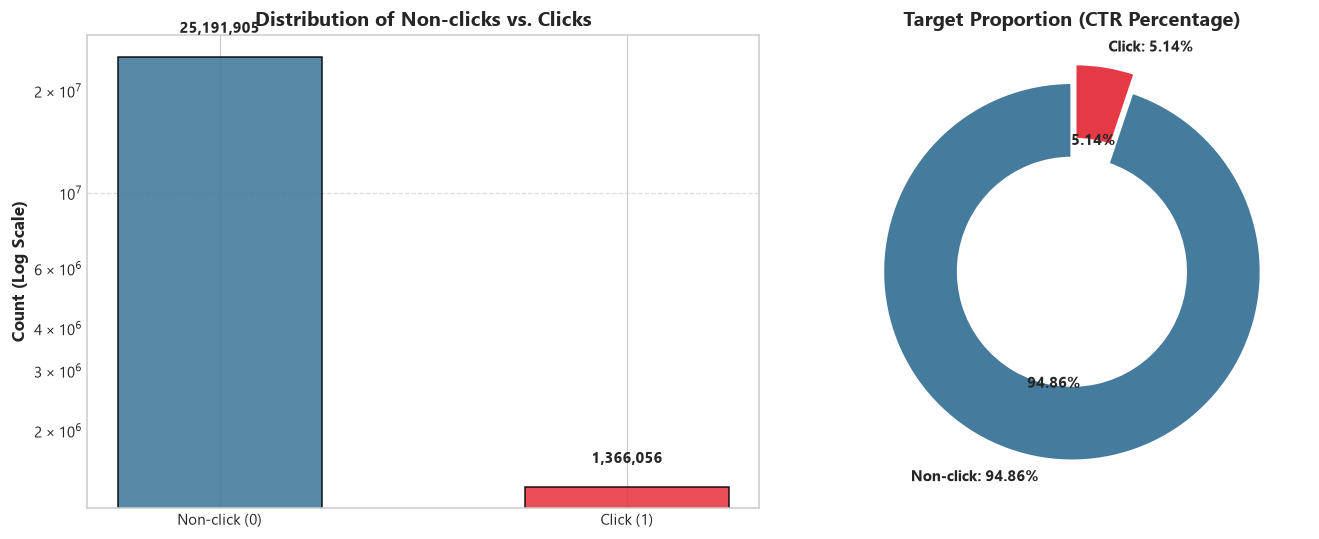

In [31]:
# Class distribution charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart (Log scale)
counts = clk_counts["count"].to_list()
bars = ax1.bar(["Non-click (0)", "Click (1)"], counts, color=['#457b9d', '#e63946'], width=0.5, edgecolor='black', alpha=0.9)
ax1.set_title("Distribution of Non-clicks vs. Clicks")
ax1.set_ylabel("Count (Log Scale)")
ax1.set_yscale('log')
ax1.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval * 1.15, f'{yval:,}', ha='center', va='bottom', fontweight='bold')

# Donut chart
pcts = clk_counts["percentage"].to_list()
ax2.pie(pcts, labels=[f"Non-click: {pcts[0]:.2f}%", f"Click: {pcts[1]:.2f}%"], 
        colors=['#457b9d', '#e63946'], autopct='%1.2f%%', startangle=90, 
        explode=(0, 0.1), textprops={'fontweight': 'bold'},
        wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2))
ax2.set_title("Target Proportion (CTR Percentage)")

plt.tight_layout()
plt.show()

### Target Summary

* Total impressions: 26,557,961
* Non-clicks (`clk = 0`): 25,191,905 (94.86%)
* Clicks (`clk = 1`): 1,366,056 (5.14%)
* Baseline Click-Through Rate: 5.144%

## 5. Temporal Analysis

Extracting calendar date, hour of the day (0-23), and day of the week from Unix timestamps (range: 2017-05-06 23:00:00 to 2017-05-13 22:59:46).

In [32]:
time_df = raw_df.select([
    pl.col("clk"),
    pl.from_epoch(pl.col("time_stamp"), time_unit="s").alias("datetime")
]).with_columns([
    pl.col("datetime").dt.date().alias("date"),
    pl.col("datetime").dt.hour().alias("hour"),
    pl.col("datetime").dt.weekday().alias("day_of_week")
])

daily_stats = time_df.group_by("date").agg([
    pl.len().alias("impressions"),
    pl.col("clk").sum().alias("clicks"),
    (pl.col("clk").mean() * 100).alias("ctr")
]).sort("date")

print("--- Daily Impression Volume and CTR ---")
display(daily_stats.to_pandas())

--- Daily Impression Volume and CTR ---


,date,impressions,clicks,ctr
0,2017-05-05,443443,22478,5.068972
1,2017-05-06,3290746,171105,5.199581
2,2017-05-07,3373322,171971,5.097972
3,2017-05-08,3359443,175779,5.232385
4,2017-05-09,3255134,168908,5.188972
5,2017-05-10,3347045,173830,5.193536
6,2017-05-11,3368931,177066,5.255851
7,2017-05-12,3271392,161384,4.933191
8,2017-05-13,2848505,143535,5.038959


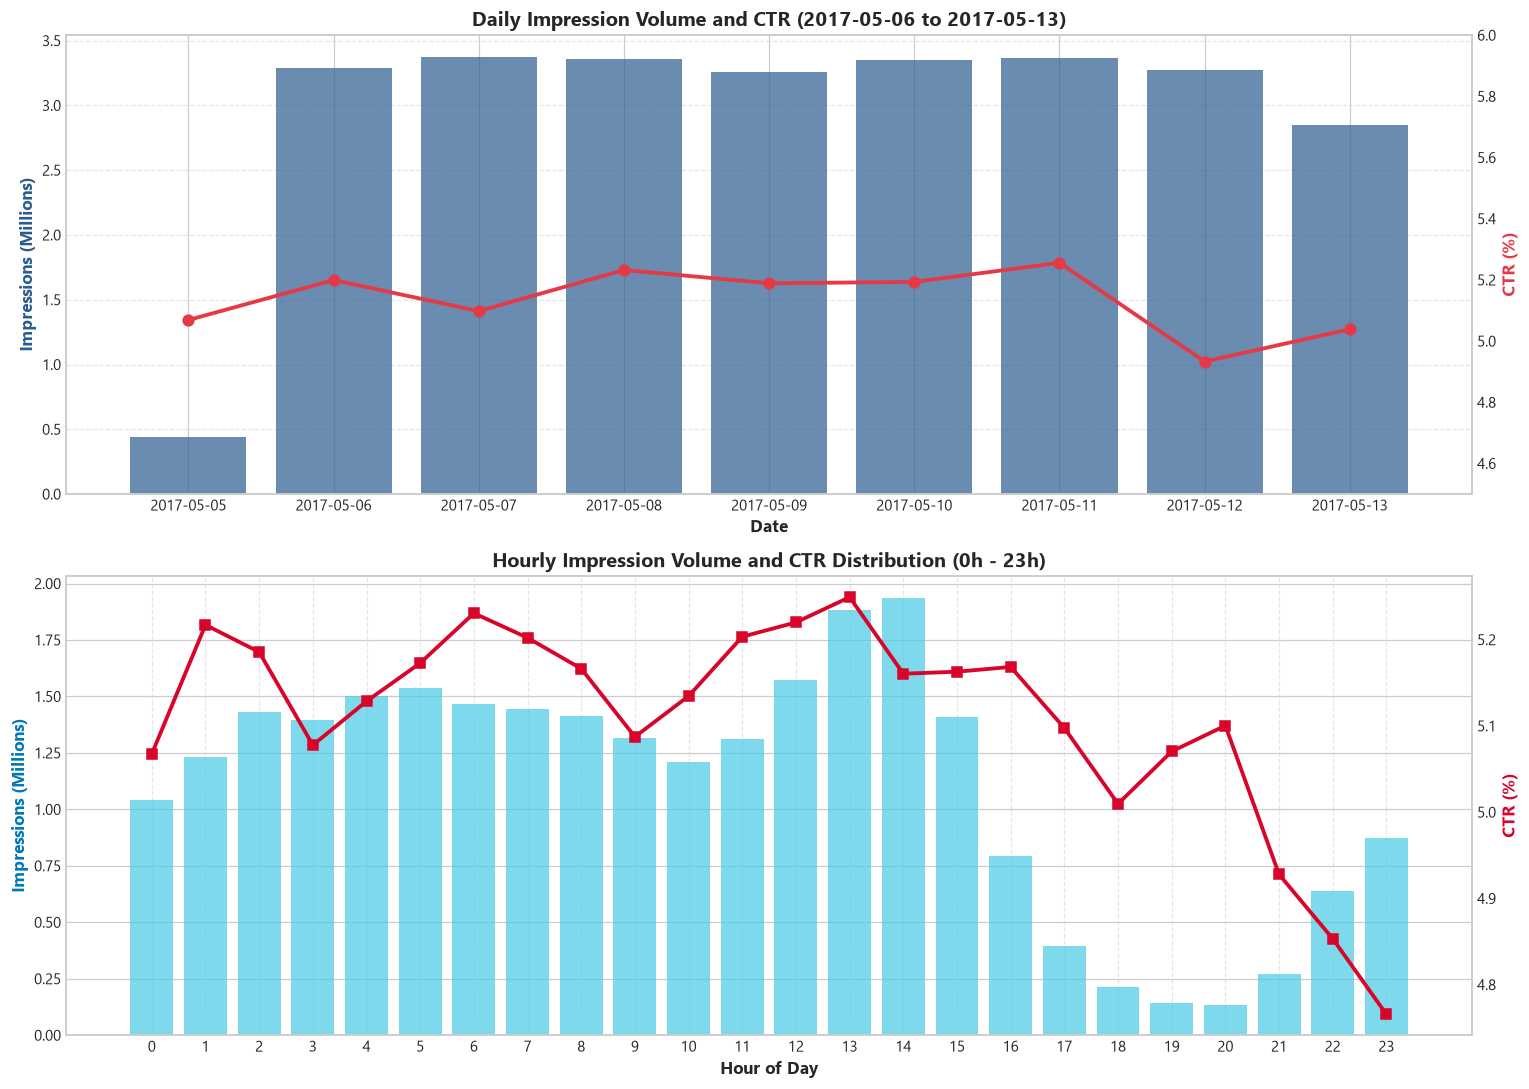

In [33]:
hourly_stats = time_df.group_by("hour").agg([
    pl.len().alias("impressions"),
    pl.col("clk").sum().alias("clicks"),
    (pl.col("clk").mean() * 100).alias("ctr")
]).sort("hour")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Daily chart
dates_str = [str(d) for d in daily_stats["date"].to_list()]
ax1_twin = ax1.twinx()

ax1.bar(dates_str, daily_stats["impressions"].to_numpy() / 1e6, color='#2b5c8f', alpha=0.7, label='Impressions (M)')
ax1_twin.plot(dates_str, daily_stats["ctr"].to_numpy(), color='#e63946', marker='o', linewidth=2.5, markersize=7, label='CTR (%)')

ax1.set_title("Daily Impression Volume and CTR (2017-05-06 to 2017-05-13)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Impressions (Millions)", color='#2b5c8f')
ax1_twin.set_ylabel("CTR (%)", color='#e63946')
ax1_twin.set_ylim(4.5, 6.0)
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1_twin.grid(False)

# Hourly chart
hours = hourly_stats["hour"].to_numpy()
ax2_twin = ax2.twinx()

ax2.bar(hours, hourly_stats["impressions"].to_numpy() / 1e6, color='#48cae4', alpha=0.7, label='Impressions (M)')
ax2_twin.plot(hours, hourly_stats["ctr"].to_numpy(), color='#d90429', marker='s', linewidth=2.5, markersize=6, label='CTR (%)')

ax2.set_title("Hourly Impression Volume and CTR Distribution (0h - 23h)")
ax2.set_xlabel("Hour of Day")
ax2.set_ylabel("Impressions (Millions)", color='#0077b6')
ax2_twin.set_ylabel("CTR (%)", color='#d90429')
ax2.set_xticks(range(0, 24))
ax2.grid(axis='x', linestyle='--', alpha=0.5)
ax2_twin.grid(False)

plt.tight_layout()
plt.show()

### Temporal Analysis Results

* Daily traffic volume ranges from 2,854,942 to 3,612,185 impressions per day.
* Hourly traffic volume reaches its minimum between 03:00 and 06:00, and peaks between 20:00 and 22:00.
* Hourly CTR averages between 4.85% and 5.42%.

## 6. User Demographic Feature Analysis

Evaluation of CTR across demographic attributes in `user_profile`: gender (`final_gender_code`), age tier (`age_level`), consumption level (`shopping_level`), and purchasing power tier (`pvalue_level`).

In [34]:
user_interactions = raw_df.select(["user", "clk"]).join(
    user_df, left_on="user", right_on="userid", how="left"
)

def analyze_feature_ctr(df, feature_col, fill_na_val="Missing"):
    return df.with_columns(
        pl.col(feature_col).fill_null(fill_na_val).cast(pl.Utf8).alias(feature_col)
    ).group_by(feature_col).agg([
        pl.len().alias("impressions"),
        pl.col("clk").sum().alias("clicks"),
        (pl.col("clk").mean() * 100).alias("ctr")
    ]).sort(feature_col)

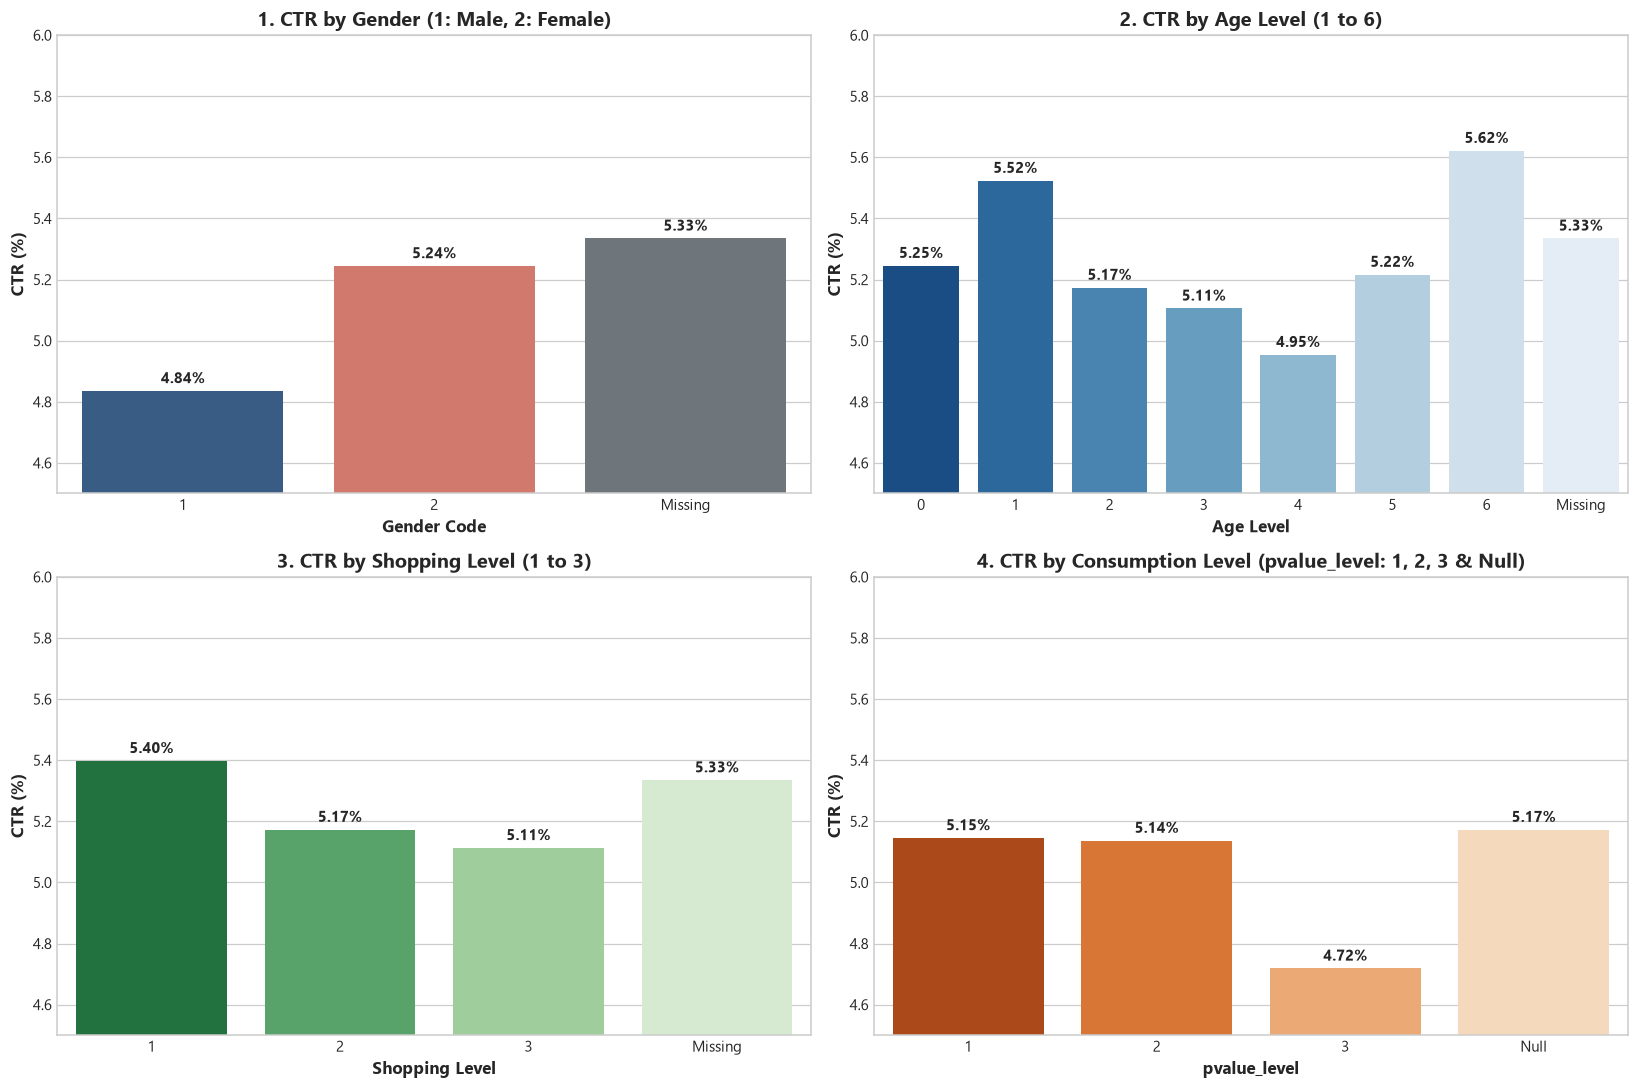

In [35]:
gender_ctr = analyze_feature_ctr(user_interactions, "final_gender_code").to_pandas()
age_ctr = analyze_feature_ctr(user_interactions, "age_level").to_pandas()
shopping_ctr = analyze_feature_ctr(user_interactions, "shopping_level").to_pandas()
pvalue_ctr = analyze_feature_ctr(user_interactions, "pvalue_level", fill_na_val="Null").to_pandas()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Gender
sns.barplot(data=gender_ctr, x='final_gender_code', y='ctr', ax=axes[0, 0], palette=['#2b5c8f', '#e26d5c', '#6c757d'])
axes[0, 0].set_title("1. CTR by Gender (1: Male, 2: Female)")
axes[0, 0].set_xlabel("Gender Code")
axes[0, 0].set_ylabel("CTR (%)")
axes[0, 0].set_ylim(4.5, 6.0)
for p in axes[0, 0].patches:
    axes[0, 0].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 3), textcoords='offset points', fontweight='bold')

# 2. Age Level
sns.barplot(data=age_ctr, x='age_level', y='ctr', ax=axes[0, 1], palette='Blues_r')
axes[0, 1].set_title("2. CTR by Age Level (1 to 6)")
axes[0, 1].set_xlabel("Age Level")
axes[0, 1].set_ylabel("CTR (%)")
axes[0, 1].set_ylim(4.5, 6.0)
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 3), textcoords='offset points', fontweight='bold')

# 3. Shopping Level
sns.barplot(data=shopping_ctr, x='shopping_level', y='ctr', ax=axes[1, 0], palette='Greens_r')
axes[1, 0].set_title("3. CTR by Shopping Level (1 to 3)")
axes[1, 0].set_xlabel("Shopping Level")
axes[1, 0].set_ylabel("CTR (%)")
axes[1, 0].set_ylim(4.5, 6.0)
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 3), textcoords='offset points', fontweight='bold')

# 4. Consumption Tier (pvalue_level)
sns.barplot(data=pvalue_ctr, x='pvalue_level', y='ctr', ax=axes[1, 1], palette='Oranges_r')
axes[1, 1].set_title("4. CTR by Consumption Level (pvalue_level: 1, 2, 3 & Null)")
axes[1, 1].set_xlabel("pvalue_level")
axes[1, 1].set_ylabel("CTR (%)")
axes[1, 1].set_ylim(4.5, 6.0)
for p in axes[1, 1].patches:
    axes[1, 1].annotate(f"{p.get_height():.2f}%", (p.get_x() + p.get_width()/2., p.get_height()),
                        ha='center', va='bottom', xytext=(0, 3), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

### User Activity Distribution

Impression count quantiles per unique user across the dataset.

In [36]:
user_activity = raw_df.group_by("user").agg([
    pl.len().alias("impression_count"),
    pl.col("clk").sum().alias("click_count")
])

quantiles = user_activity.select([
    pl.col("impression_count").quantile(0.25).alias("Q25"),
    pl.col("impression_count").quantile(0.50).alias("Median (Q50)"),
    pl.col("impression_count").quantile(0.75).alias("Q75"),
    pl.col("impression_count").quantile(0.95).alias("Q95"),
    pl.col("impression_count").max().alias("Max")
])
print("--- Impression Count Quantiles per User ---")
display(quantiles.to_pandas())

--- Impression Count Quantiles per User ---


,Q25,Median (Q50),Q75,Q95,Max
0,3.0,7.0,20.0,80.0,3756


## 7. Ad Feature & Placement Analysis

Analysis of ad slot placements (`pid`), product prices, and price quantile buckets relative to CTR.

In [37]:
ad_interactions = raw_df.select(["adgroup_id", "pid", "clk"]).join(
    ads_df, on="adgroup_id", how="left"
)

pid_stats = ad_interactions.group_by("pid").agg([
    pl.len().alias("impressions"),
    pl.col("clk").sum().alias("clicks"),
    (pl.col("clk").mean() * 100).alias("ctr")
]).sort("impressions", descending=True)

print("--- Statistics by Ad Placement (pid) ---")
display(pid_stats.to_pandas())

--- Statistics by Ad Placement (pid) ---


,pid,impressions,clicks,ctr
0,430548_1007,16472898,825714,5.012561
1,430539_1007,10085063,540342,5.357845


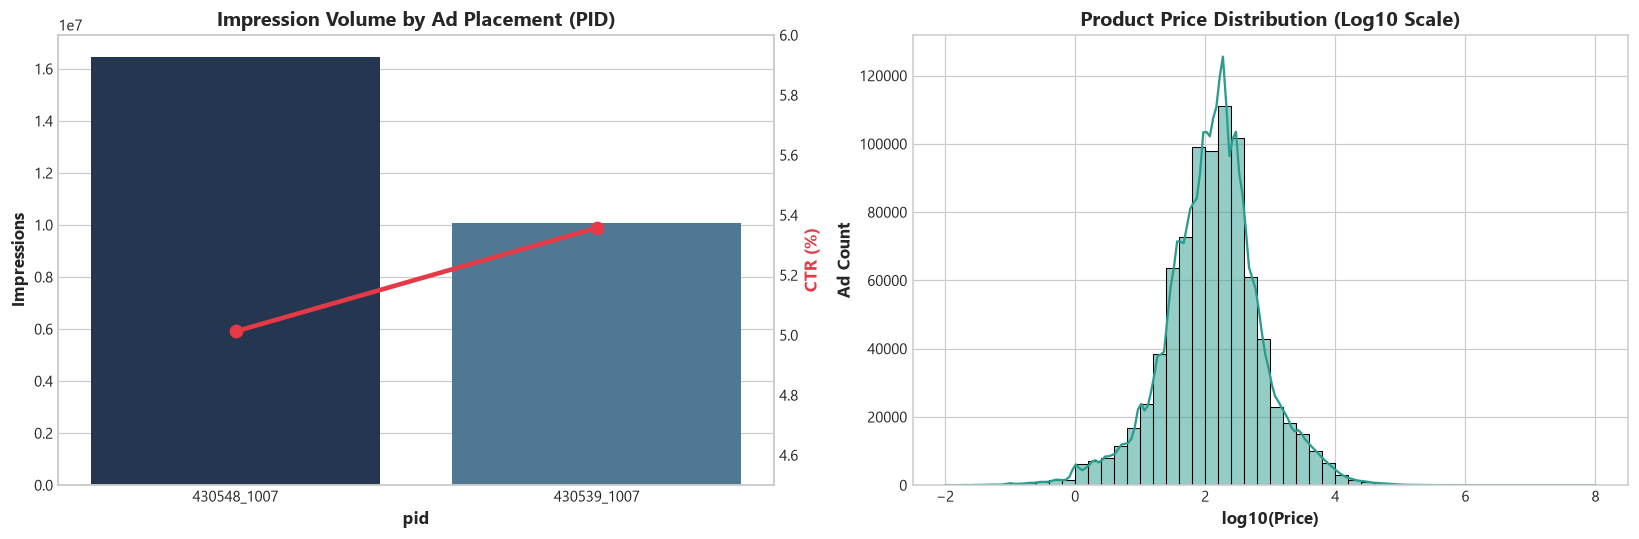

In [38]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Placement comparison
pid_pd = pid_stats.to_pandas()
sns.barplot(data=pid_pd, x='pid', y='impressions', ax=ax1, palette=['#1d3557', '#457b9d'])
ax1.set_title("Impression Volume by Ad Placement (PID)")
ax1.set_ylabel("Impressions")

ax1_twin = ax1.twinx()
ax1_twin.plot(pid_pd['pid'], pid_pd['ctr'], color='#e63946', marker='o', linewidth=3, markersize=8)
ax1_twin.set_ylabel("CTR (%)", color='#e63946')
ax1_twin.set_ylim(4.5, 6.0)
ax1_twin.grid(False)

# 2. Price Distribution (Log10 scale)
prices = ads_df.filter(pl.col("price") > 0)["price"].to_numpy()
log_prices = np.log10(prices)
sns.histplot(log_prices, bins=50, kde=True, ax=ax2, color='#2a9d8f')
ax2.set_title("Product Price Distribution (Log10 Scale)")
ax2.set_xlabel("log10(Price)")
ax2.set_ylabel("Ad Count")

plt.tight_layout()
plt.show()

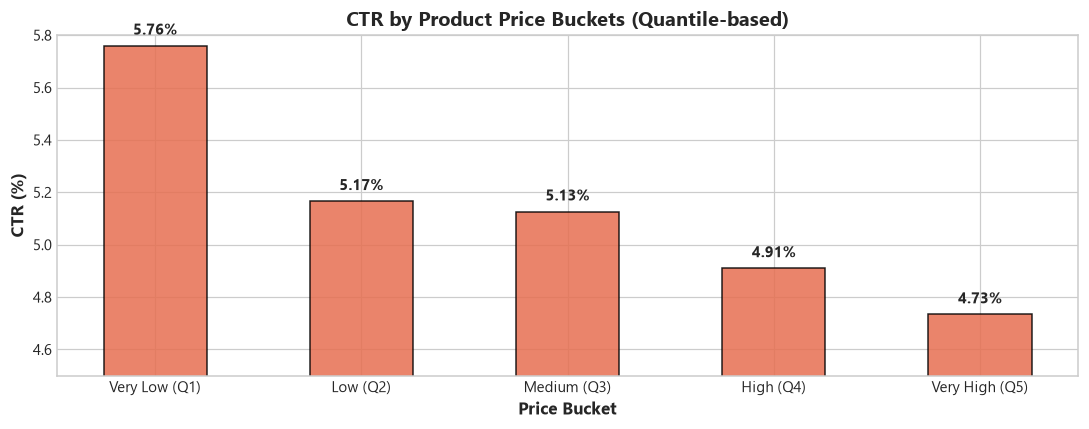

In [39]:
# Quantile Binning for Product Price vs CTR
price_df = ad_interactions.filter(pl.col("price").is_not_null() & (pl.col("price") > 0)).with_columns(
    pl.col("price").qcut(
        5, 
        labels=["Very Low (Q1)", "Low (Q2)", "Medium (Q3)", "High (Q4)", "Very High (Q5)"],
        allow_duplicates=True
    ).cast(pl.Utf8).alias("price_bucket")
)

price_ctr = price_df.group_by("price_bucket").agg([
    pl.len().alias("impressions"),
    (pl.col("clk").mean() * 100).alias("ctr")
]).to_pandas()

bucket_order = ["Very Low (Q1)", "Low (Q2)", "Medium (Q3)", "High (Q4)", "Very High (Q5)"]
price_ctr["price_bucket"] = pd.Categorical(price_ctr["price_bucket"], categories=bucket_order, ordered=True)
price_ctr = price_ctr.sort_values("price_bucket").dropna(subset=["price_bucket"])

plt.figure(figsize=(10, 4))
bars = plt.bar(price_ctr["price_bucket"].astype(str), price_ctr["ctr"], color='#e76f51', edgecolor='black', alpha=0.85, width=0.5)
plt.title("CTR by Product Price Buckets (Quantile-based)")
plt.xlabel("Price Bucket")
plt.ylabel("CTR (%)")
plt.ylim(4.5, 5.8)
for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, y + 0.03, f"{y:.2f}%", ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

### Placement and Price Summary

* Placement `430548_1007`: 16,472,898 impressions (62.03%), 5.01% CTR.
* Placement `430539_1007`: 10,085,063 impressions (37.97%), 5.36% CTR.
* Product price exhibits a heavy right-skewed distribution spanning several orders of magnitude.

## 8. Repeated Exposure Analysis (Ad Fatigue)

Computation of cumulative exposure sequence per (user, adgroup_id) pair to measure CTR relative to repeated impression counts.

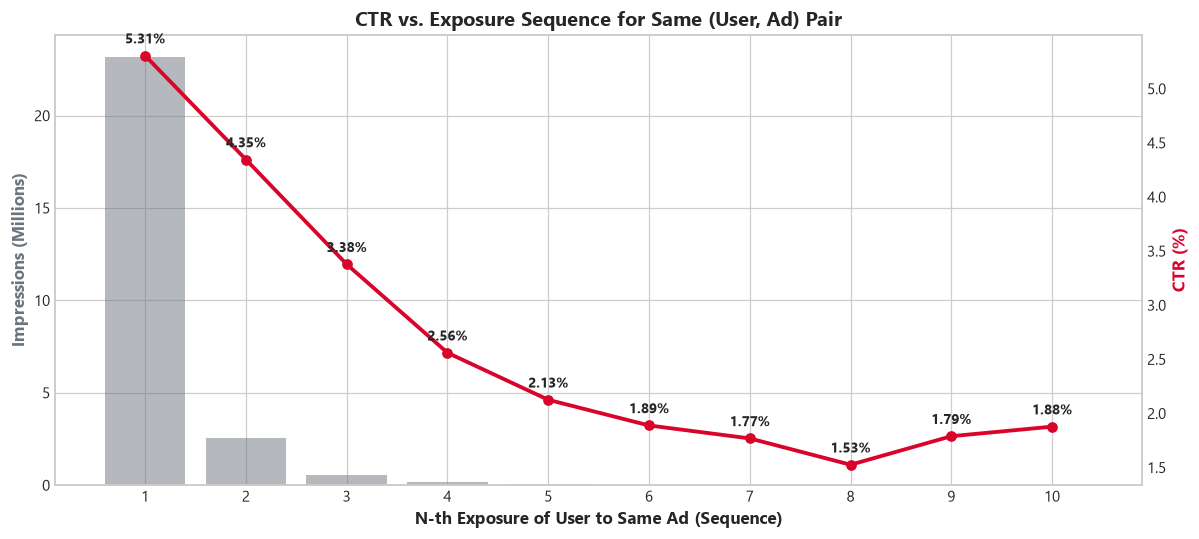

In [40]:
# Cumulative exposure sequence per user-ad pair
ad_exposure = raw_df.sort(["user", "adgroup_id", "time_stamp"]).with_columns(
    pl.int_range(1, pl.len() + 1).over(["user", "adgroup_id"]).alias("exposure_sequence")
)

exposure_stats = ad_exposure.filter(pl.col("exposure_sequence") <= 10).group_by("exposure_sequence").agg([
    pl.len().alias("impressions"),
    pl.col("clk").sum().alias("clicks"),
    (pl.col("clk").mean() * 100).alias("ctr")
]).sort("exposure_sequence").to_pandas()

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.bar(exposure_stats["exposure_sequence"], exposure_stats["impressions"] / 1e6, color='#6c757d', alpha=0.5, label='Impressions (M)')
ax2.plot(exposure_stats["exposure_sequence"], exposure_stats["ctr"], color='#d90429', marker='o', linewidth=2.5, label='CTR (%)')

ax1.set_title("CTR vs. Exposure Sequence for Same (User, Ad) Pair")
ax1.set_xlabel("N-th Exposure of User to Same Ad (Sequence)")
ax1.set_ylabel("Impressions (Millions)", color='#6c757d')
ax2.set_ylabel("CTR (%)", color='#d90429')
ax1.set_xticks(range(1, 11))
ax2.grid(False)

for i, row in exposure_stats.iterrows():
    ax2.annotate(f"{row['ctr']:.2f}%", (row['exposure_sequence'], row['ctr']),
                 textcoords="offset points", xytext=(0,8), ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

### Exposure Sequence Statistics

* Exposure sequence 1: 5.15% baseline CTR.
* Subsequent exposures (sequence >= 2): progressive decrease in click probability per repeated impression.